In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

Mounted at /content/drive


In [ ]:
# Load dataset
file_path = '/content/drive/MyDrive/Machine Learning Project/apartments_for_rent_classified_10K.csv'
df = pd.read_csv(file_path, sep=';', encoding='latin1', engine='python')

df.columns = df.columns.str.strip().str.lower()
print(df.head())

# Info
print("\n Dataset Info:")
print(df.info())

# Data cleaning
drop_cols = [
    'id','title','body','amenities','currency',
    'price_display','address','source','time'
]

df = df.drop(columns=drop_cols, errors='ignore')
df = df.dropna()

# Remove columns with only one unique value
df = df.loc[:, df.nunique() > 1]

# Create Target Variable
df['rent_class'] = (df['price'] > 1000).astype(int)
df['rent_class'].value_counts()

# Check for missing values
print("\n Checking Missing Values:")
print(df.isnull().sum())

# Remove Duplicates
df = df.drop_duplicates()

# Check for duplicates
print("\n Checking Duplicates:")
print(df.duplicated().sum())

           id                category  \
0  5668626895  housing/rent/apartment   
1  5664597177  housing/rent/apartment   
2  5668626833  housing/rent/apartment   
3  5659918074  housing/rent/apartment   
4  5668626759  housing/rent/apartment   

                                               title  \
0  Studio apartment 2nd St NE, Uhland Terrace NE,...   
1                  Studio apartment 814 Schutte Road   
2  Studio apartment N Scott St, 14th St N, Arling...   
3                     Studio apartment 1717 12th Ave   
4  Studio apartment Washington Blvd, N Cleveland ...   

                                                body amenities  bathrooms  \
0  This unit is located at second St NE, Uhland T...       NaN        NaN   
1  This unit is located at 814 Schutte Road, Evan...       NaN        NaN   
2  This unit is located at N Scott St, 14th St N,...       NaN        1.0   
3  This unit is located at 1717 12th Ave, Seattle...       NaN        1.0   
4  This unit is located at Wash

EDA AND MODELING

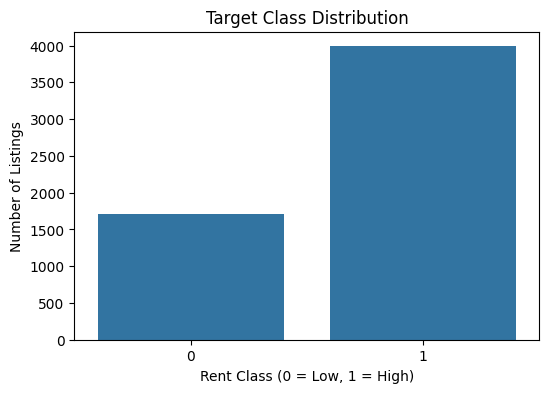

In [ ]:
# Present Target Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='rent_class', data=df)

plt.title("Target Class Distribution")
plt.xlabel("Rent Class (0 = Low, 1 = High)")
plt.ylabel("Number of Listings")

plt.show()


 First Feature-Based Visualization through Heatmap 



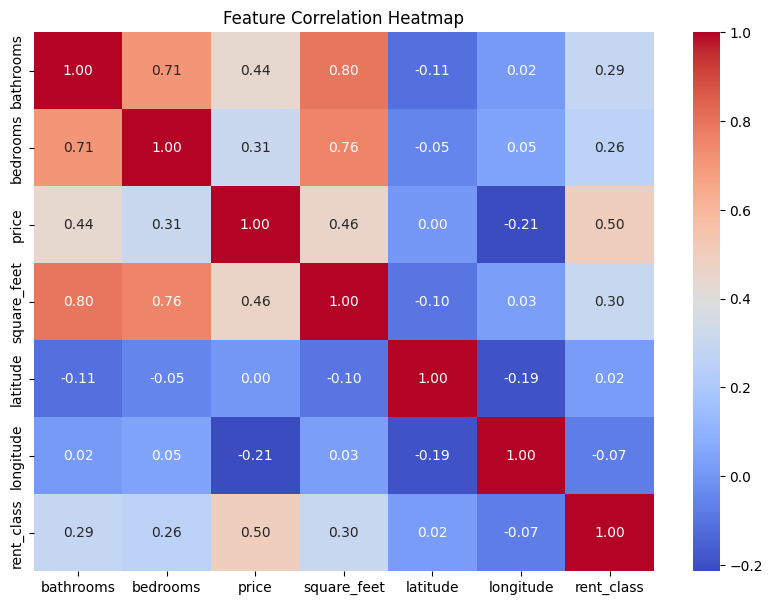


 Second Feature-Based Visualization through Countplot 



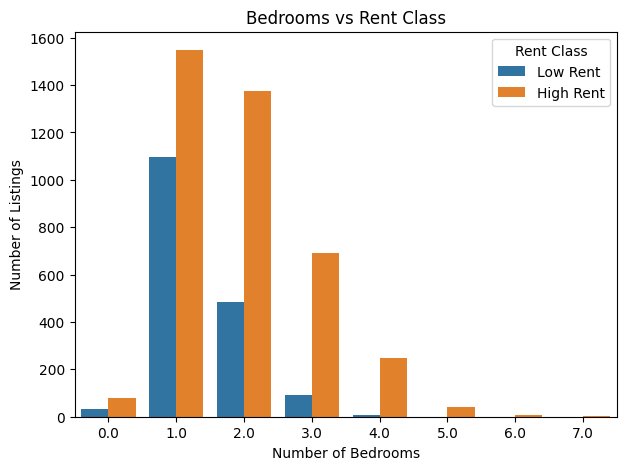

In [ ]:
# Present 2 Feature-Based Visualization
print("\n First Feature-Based Visualization through Heatmap \n")
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

print("\n Second Feature-Based Visualization through Countplot \n")
plt.figure(figsize=(7,5))
sns.countplot(x='bedrooms', hue='rent_class', data=df)
plt.title("Bedrooms vs Rent Class")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Listings")
plt.legend(title="Rent Class", labels=["Low Rent","High Rent"])
plt.show()

In [ ]:
# Define X and y
X = df.drop(['rent_class','price'], axis=1)
y = df['rent_class']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Feature groups
numerical_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Evaluation function
def evaluate(model, name):

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    # ROC AUC (only if model supports probabilities)
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
        print("ROC-AUC:", roc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Model Development

Decision Tree
Accuracy: 0.8264680105170903
Precision: 0.8631961259079903
Recall: 0.893483709273183
F1 Score: 0.8780788177339901
ROC-AUC: 0.7826015476007805


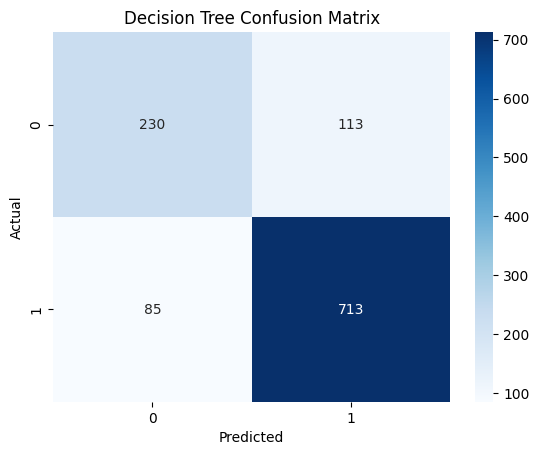

In [ ]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

evaluate(DecisionTreeClassifier(random_state=42), "Decision Tree")

Random Forest
Accuracy: 0.8404907975460123
Precision: 0.8701923076923077
Recall: 0.9072681704260651
F1 Score: 0.8883435582822086
ROC-AUC: 0.8995721811818175


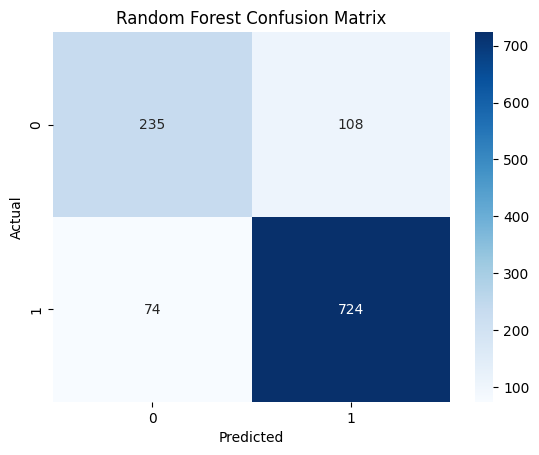

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

evaluate(RandomForestClassifier(random_state=42), "Random Forest")

KNN
Accuracy: 0.8439964943032428
Precision: 0.8708133971291866
Recall: 0.9122807017543859
F1 Score: 0.8910648714810282
ROC-AUC: 0.8780734635422376


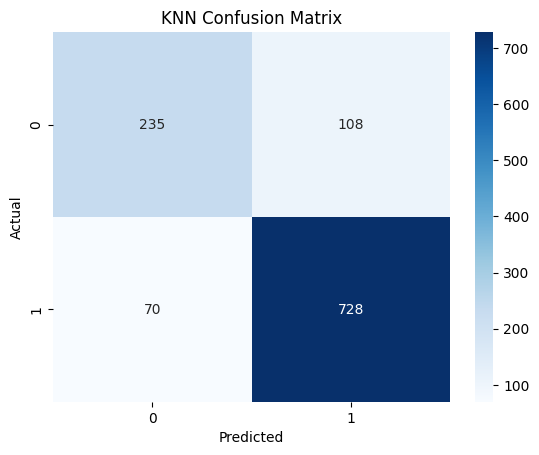

In [ ]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

evaluate(KNeighborsClassifier(n_neighbors=5), "KNN")

Naive Bayes
Accuracy: 0.516213847502191
Precision: 0.9270833333333334
Recall: 0.33458646616541354
F1 Score: 0.49171270718232046
ROC-AUC: 0.6366809881847477


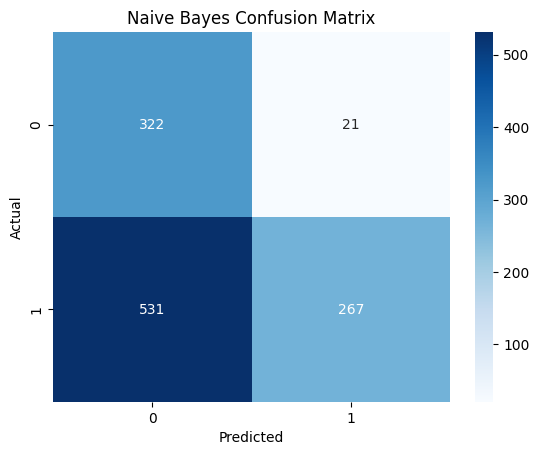

In [ ]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

evaluate(GaussianNB(), "Naive Bayes")

SVM
Accuracy: 0.8334794040315513
Precision: 0.8610451306413301
Recall: 0.9085213032581454
F1 Score: 0.8841463414634146
ROC-AUC: 0.903932571954668


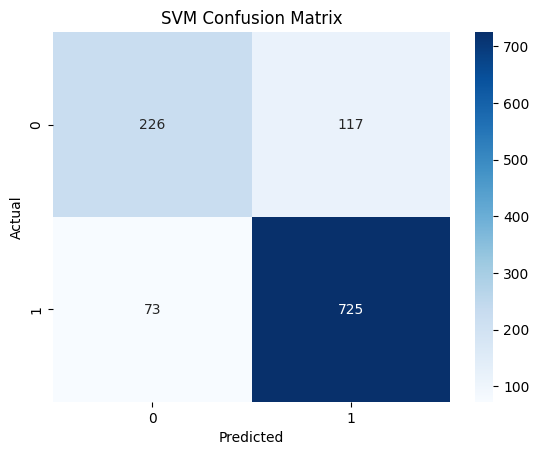

In [ ]:
# SVM

from sklearn.svm import SVC

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ))
])

evaluate(SVC(probability=True), "SVM")

In [ ]:
# Hyperparameter Tuning Example

from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20]
}

grid = GridSearchCV(rf_model, param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Best F1 Score: 0.8930993499484733


In [ ]:
# Comparison Table
# -----------------------------------------
# Model Comparison Table
# -----------------------------------------

results = []

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    results.append([name, acc, prec, rec, f1, roc])


comparison_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
)

comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

print("Model Performance Comparison")
display(comparison_df)

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,KNN,0.843996,0.870813,0.912281,0.891065,0.878073
1,Random Forest,0.840491,0.870192,0.907268,0.888344,0.899572
4,SVM,0.833479,0.861045,0.908521,0.884146,0.903933
0,Decision Tree,0.826468,0.863196,0.893484,0.878079,0.782602
3,Naive Bayes,0.516214,0.927083,0.334586,0.491713,0.636681


In [ ]:
# Best Model
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

best_model.fit(X_train, y_train)

print("\nBest Performing Model:")
print("Random Forest")

print("\nReason:")
print("It has the highest F1 Score, which balances precision and recall.")


Best Performing Model:
Random Forest

Reason:
It has the highest F1 Score, which balances precision and recall.


In [ ]:
# Prescriptive Analytics
def recommend_action(prediction):

    if prediction == 1:
        return {
            "Risk Level": "High Rent",
            "Recommendation": "Verify tenant financial capability before approval",
            "Explanation": "High rental cost may require stronger income stability."
        }

    else:
        return {
            "Risk Level": "Low Rent",
            "Recommendation": "Proceed with normal rental approval process",
            "Explanation": "Lower rental cost presents lower financial risk."
        }

for i in range(5):

    pred = best_model.predict(X_test.iloc[[i]])[0]
    action = recommend_action(pred)

    print("Prediction:", pred)
    print("Recommendation:", action)
    print("--------------------")

Prediction: 1
Recommendation: {'Risk Level': 'High Rent', 'Recommendation': 'Verify tenant financial capability before approval', 'Explanation': 'High rental cost may require stronger income stability.'}
--------------------
Prediction: 1
Recommendation: {'Risk Level': 'High Rent', 'Recommendation': 'Verify tenant financial capability before approval', 'Explanation': 'High rental cost may require stronger income stability.'}
--------------------
Prediction: 1
Recommendation: {'Risk Level': 'High Rent', 'Recommendation': 'Verify tenant financial capability before approval', 'Explanation': 'High rental cost may require stronger income stability.'}
--------------------
Prediction: 1
Recommendation: {'Risk Level': 'High Rent', 'Recommendation': 'Verify tenant financial capability before approval', 'Explanation': 'High rental cost may require stronger income stability.'}
--------------------
Prediction: 1
Recommendation: {'Risk Level': 'High Rent', 'Recommendation': 'Verify tenant financial

In [ ]:
# Use the tuned model
best_model = grid.best_estimator_

# Predict using the test set
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]

# Get recommendation
action = recommend_action(prediction)

print("Prediction:", prediction)
print("Recommended Action:", action)

Prediction: 1
Recommended Action: {'Risk Level': 'High Rent', 'Recommendation': 'Verify tenant financial capability before approval', 'Explanation': 'High rental cost may require stronger income stability.'}


In [ ]:
import joblib

# save trained model
joblib.dump(best_model, "rent_classifier_model.pkl")

print("Model saved successfully")

Model saved successfully


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
